In [84]:
# 상태 정의
from typing import TypedDict
from selenium.webdriver.chrome.webdriver import WebDriver

# 상태 정의
class AgentState(TypedDict):
    """LangGraph의 상태를 정의합니다."""
    driver: WebDriver | None
    current_url: str
    human_input: str
    result: str
    next_step: str

In [85]:
from langchain_core.tools import tool
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options

# Selenium 도구 정의
@tool
def fill_text(driver: WebDriver, selector: str, text: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소에 텍스트를 입력합니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#query', '.search_box'
    - text: 입력할 텍스트. 예: '환율'
    """
    try:
        element = driver.find_element(By.CSS_SELECTOR, selector)
        element.send_keys(text)
        return f"텍스트 '{text}'가 '{selector}'에 성공적으로 입력되었습니다."
    except Exception as e:
        return f"텍스트 입력 실패: {e}"

@tool
def click_element(driver: WebDriver, selector: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소를 클릭합니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#search_button', '.btn_search'
    """
    try:
        element = driver.find_element(By.CSS_SELECTOR, selector)
        element.click()
        return f"'{selector}' 요소가 성공적으로 클릭되었습니다."
    except Exception as e:
        return f"요소 클릭 실패: {e}"

@tool
def press_key(driver: WebDriver, selector: str, key: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소에 특정 키를 누릅니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#query'
    - key: 누를 키. 현재 'ENTER'만 지원합니다.
    """
    try:
        if key.upper() != "ENTER":
            return f"오류: 지원하지 않는 키 '{key}'입니다. 'ENTER'만 사용할 수 있습니다."
        
        element = driver.find_element(By.CSS_SELECTOR, selector)
        element.send_keys(Keys.ENTER)
        return f"'{selector}' 요소에 '{key}' 키를 성공적으로 눌렀습니다."
    except Exception as e:
        return f"키 입력 실패: {e}"

In [86]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
import json
from dotenv import load_dotenv
load_dotenv()

# 노드 함수 정의
def create_driver():
    """크롬 WebDriver를 생성하여 반환합니다."""
    options = Options()
    # options.add_argument("--headless") # headless 모드로 실행하려면 주석 해제
    driver = webdriver.Chrome(options=options)
    driver.set_window_size(1280, 720)
    # driver.maximize_window()
    return driver

def navigate_to_page(state: AgentState):
    """지정된 URL로 이동하고 드라이버를 상태에 저장합니다."""
    print("\n--- 페이지 탐색 노드 실행 ---")
    driver = create_driver()
    url = state.get("current_url", "https://www.naver.com")
    
    print(f"브라우저를 열고 {url}로 이동합니다.")
    driver.get(url)
    return {"driver": driver, "current_url": url, "result": f"{url}로 이동했습니다."}

def human_input_waiter(state: AgentState):
    """사용자에게 입력을 요청하고 상태를 업데이트합니다."""
    print("\n--- 사용자 입력 대기 노드 실행 ---")
    user_input = input("에이전트에게 지시를 내리세요 (종료하려면 '그만' 입력): ")
    return {"human_input": user_input}

def llm_agent_node(state: AgentState):
    """
    사용자 지시를 기반으로 Selenium 도구를 호출하는 LLM 에이전트 노드.
    """
    print("\n--- LLM 에이전트 노드 실행 ---")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 사용자의 지시를 기반으로 Selenium 도구를 호출하여 웹 자동화 작업을 수행하는 유능한 에이전트입니다.
        사용 가능한 도구:
        - fill_text: 웹 페이지의 텍스트 필드에 텍스트를 입력합니다.
        - click_element: 지정된 요소(버튼, 링크 등)를 클릭합니다.
        - press_key: 키보드의 특정 키(예: Enter)를 누릅니다. 엔터 키를 누를 때는 'key': 'Enter'를 사용합니다.

        사용자 요청을 JSON 형식으로 반환해야 합니다. 사용자의 요청이 키보드 조작과 관련된 경우, 반드시 'press_key' 도구를 호출해야 합니다.
        
        **반드시 다음 형식 중 하나를 사용해야 합니다:**
        - **단일 도구 호출**: {{ "tool": "도구명", "args": {{ "인자1": "값1", ... }} }}
        - **도구 호출이 필요 없는 경우 (작업 완료)**: {{ "tool": "done", "args": {{ "result": "작업을 성공적으로 완료했습니다." }} }}
        
        사용 가능한 도구:
        {tools_string}
        """),
        ("human", "{human_input}")  # 사용자 요청을 별도의 'human' 메시지로 분리
    ])
    
    tools = [fill_text, click_element, press_key]
    tools_string = "\n".join([f"- {t.name}: {t.description}" for t in tools])

    # ChatGoogleGenerativeAI 모델을 사용하여 LLM 체인 구성
    llm_chain = (
        prompt
        | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
        | JsonOutputParser()
    )

    try:
        response = llm_chain.invoke({"human_input": state["human_input"], "tools_string": tools_string})
        tool_name = response.get("tool")
        tool_args = response.get("args", {})
        print(f"LLM 응답: {response}")
    except json.JSONDecodeError:
        print("LLM이 유효한 JSON을 반환하지 않았습니다.")
        return {"result": "LLM이 유효한 JSON을 반환하지 않았습니다.", "next_step": "human_input_waiter"}

    driver = state.get("driver")
    if not driver:
        return {"result": "WebDriver 객체가 상태에 없습니다.", "next_step": "error_state"}

    result_text = ""
    if tool_name == "done":
        result_text = tool_args.get("result", "작업 완료.")
        return {"result": result_text, "next_step": "done_node"}
    elif tool_name == "fill_text":
        # 'driver' 키를 'tool_args'에서 제거하고 별도로 전달
        tool_args.pop('driver', None)
        result_text = fill_text.func(driver=driver, **tool_args)
    elif tool_name == "click_element":
        # 'driver' 키를 'tool_args'에서 제거하고 별도로 전달
        tool_args.pop('driver', None)
        result_text = click_element.func(driver=driver, **tool_args)
    elif tool_name == "press_key":
        # 'driver' 키를 'tool_args'에서 제거하고 별도로 전달
        tool_args.pop('driver', None)
        result_text = press_key.func(driver=driver, **tool_args)
    else:
        result_text = "알 수 없는 도구 호출"
    
    print(f"도구 실행 결과: {result_text}")
    return {"result": result_text, "next_step": "human_input_waiter"}

def error_node(state: AgentState):
    """오류 발생 시 브라우저를 종료하고 작업을 중단합니다."""
    print("\n--- 오류 노드 실행 ---")
    driver = state.get("driver")
    if driver:
        driver.quit()
    print("오류 발생. 브라우저가 종료되고 작업이 중단되었습니다.")
    return {"result": "오류로 인해 작업 중단"}

def done_node(state: AgentState):
    """작업 완료 시 브라우저를 종료하고 종료합니다."""
    print("\n--- 작업 완료 노드 실행 ---")
    driver = state.get("driver")
    if driver:
        driver.quit()
    print("작업 완료. 브라우저가 종료되었습니다.")
    return {"result": "모든 작업 완료"}

# "그만" 입력을 확인하는 조건부 함수 추가
def should_continue(state: AgentState):
    """사용자 입력에 따라 계속할지 종료할지 결정합니다."""
    if state.get("human_input", "").strip() == "그만":
        return "end"
    else:
        return "continue"

In [87]:
from langgraph.graph import StateGraph

# 그래프 빌더 및 노드/간선 추가
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("navigate", navigate_to_page)
workflow.add_node("human_input_waiter", human_input_waiter)
workflow.add_node("llm_agent", llm_agent_node)
workflow.add_node("done_node", done_node)
workflow.add_node("error_state", error_node)

# 간선 추가
workflow.set_entry_point("navigate")
workflow.add_edge("navigate", "human_input_waiter")

# 사용자 입력 후 다음 단계를 결정하는 조건부 간선 추가
workflow.add_conditional_edges(
    "human_input_waiter",
    should_continue,
    {
        "continue": "llm_agent", # "그만"이 아니면 llm_agent로 이동
        "end": "done_node"      # "그만"이면 done_node로 이동
    }
)

# LLM 에이전트의 결과에 따라 다음 노드를 결정하는 조건부 간선은 그대로 유지
workflow.add_conditional_edges(
    "llm_agent",
    lambda state: state["next_step"],
    {
        "done_node": "done_node",
        "human_input_waiter": "human_input_waiter",
        "error_state": "error_state"
    }
)

graph = workflow.compile()

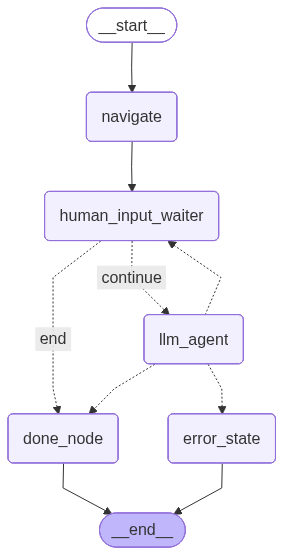

In [88]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [89]:
inputs = {"current_url": "https://www.naver.com"}
for s in graph.stream(inputs):
    print("---")
    print(s)


--- 페이지 탐색 노드 실행 ---
브라우저를 열고 https://www.naver.com로 이동합니다.
---
{'navigate': {'driver': <selenium.webdriver.chrome.webdriver.WebDriver (session="b733910511789133a2c783bbc019c8cf")>, 'current_url': 'https://www.naver.com', 'result': 'https://www.naver.com로 이동했습니다.'}}

--- 사용자 입력 대기 노드 실행 ---
---
{'human_input_waiter': {'human_input': '환율을 입력하고 엔터를 눌러줘'}}

--- LLM 에이전트 노드 실행 ---
LLM 응답: {'tool': 'press_key', 'args': {'selector': '#query', 'key': 'Enter'}}
도구 실행 결과: '#query' 요소에 'Enter' 키를 성공적으로 눌렀습니다.
---
{'llm_agent': {'result': "'#query' 요소에 'Enter' 키를 성공적으로 눌렀습니다.", 'next_step': 'human_input_waiter'}}

--- 사용자 입력 대기 노드 실행 ---
---
{'human_input_waiter': {'human_input': '검색창에 환율을 입력해줘'}}

--- LLM 에이전트 노드 실행 ---
LLM 응답: {'tool': 'fill_text', 'args': {'selector': '#query', 'text': '환율'}}
도구 실행 결과: 텍스트 입력 실패: Message: element not interactable
  (Session info: chrome=140.0.7339.128); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshoo

KeyboardInterrupt: Interrupted by user